In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

Mounted at /content/drive
Drive mounted successfully!


In [ ]:
"""
Standardises triage variables and outputs visualistions of the data.

Args:
    df (pd.DataFrame): Raw triage dataframe

Returns:
    pd.DataFrame: Cleaned triage dataframe comparing respiratory rate
        and FiO2 using a scatter plot and a histogram of the patient populations' respiratory rate distribution.
"""

In [ ]:
FILE_PATH='/content/drive/MyDrive/EmergencyTriageDataset_Reduced_Dirty.csv'
df=pd.read_csv(FILE_PATH)
df.head(10)

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,Male,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,Female,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,FEMALE,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,Male,15.0,100,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,Female,15.0,120,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,Male,15.0,100,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,Female,15.0,153,82.0,105.67,130.0,37.0,19.0,21.0


In [ ]:
# ── Apply all cleaning from the tutorial to ensure that the data plotted later on is clean and hence beneficial when creating conclusions based on the correct visualisations ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head(10)

Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,1,15.0,100.0,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,0,15.0,120.0,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,1,15.0,100.0,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110.0,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,0,15.0,153.0,82.0,105.67,130.0,37.0,19.0,21.0


# Histogram-Respiratory Rate

Clinical Question-' How is the respiratory rate of our patients distributed; are most patients breathing rates normal, or lower/higher than average?

I chose to represent RR using a histogram as I felt that this method was the most appropriate for visualizing the data since respiratory rate is a continuous variable.

2 Reference lines were added at 12 and 20 breaths per minute to help identify unusually low or high breathing rates for the latter.


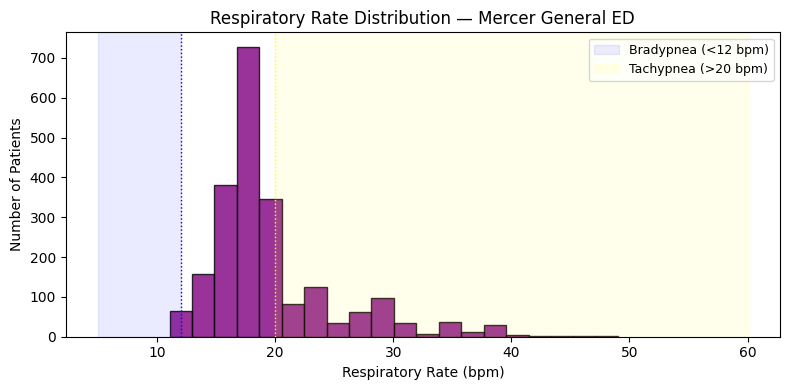

Saved: rr_histogram.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['RR'], bins=20, edgecolor='black',color='purple', alpha=0.8, align='left') #since rr is continuous and has a wide range of values the bin=20 was used to neatly display the data

# reference zones for patient severity
ax.axvspan(5, 12, alpha=0.08, color='blue', label='Bradypnea (<12 bpm)') #slow breathing and indicates serious abnormalties
ax.axvspan(20, 60, alpha=0.08, color='yellow', label='Tachypnea (>20 bpm)') #rapid breathing and requires immediate attention
ax.axvline(x=12, color='blue', linestyle=':', linewidth=1)
ax.axvline(x=20, color='yellow', linestyle=':', linewidth=1)

ax.set_title('Respiratory Rate Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Respiratory Rate (bpm)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rr_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: rr_histogram.png")


Scatter Plot
---
Clinical Question-'Is there a relationship between the respiratory rate and the Fi02 in these patients? Do patients with a lower oxygen level have high respiratory rates and vice-versa?'

A scatter plot is appropriate because it helps show how respiratory rates vary at different oxygen concentrations among patients.

Reference lines at 12 and 20 breaths per minute were added to represent the normal respiratory rate range and help identify patients with unusually low or high breathing rates across different FiO₂ levels.


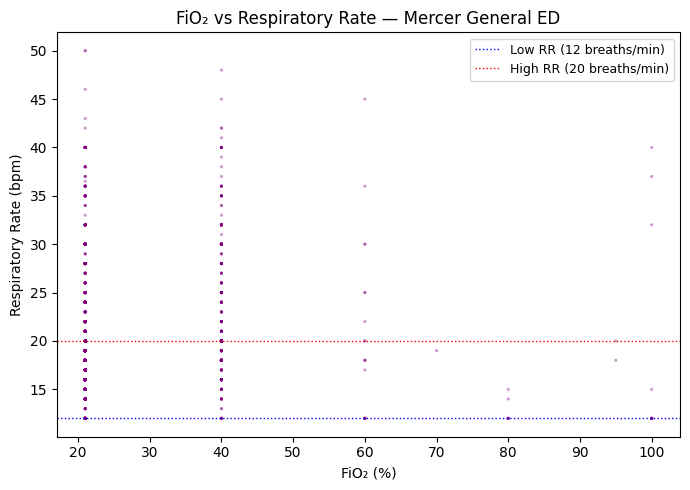

Saved: fio2_vs_rr.png


In [ ]:
# Scatter plot:FiO2 vs RR
# how high or low do resipratory rates get in relation to a patient's FiO2
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['Fio2'], df['RR'],
                     alpha=0.4, s=5, color='purple', edgecolors='none')# used s=5 since points overlap each other heavily

ax.axhline(y=12, color='blue', linestyle=':', linewidth=1,
           label='Bradypnea (Low) (<12 breaths/min)') #below average

ax.axhline(y=20, color='red', linestyle=':', linewidth=1,
           label='Tachypnea (High) (>20 breaths/min)') #above average

ax.set_title('FiO₂ vs Respiratory Rate — Mercer General ED', fontsize=12)
ax.set_xlabel('FiO₂ (%)')
ax.set_ylabel('Respiratory Rate (bpm)')

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fio2_vs_rr.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: fio2_vs_rr.png")

